# Testing trajectories to make realistic simulations

In [25]:
import matplotlib.pyplot as plt
import numpy as np



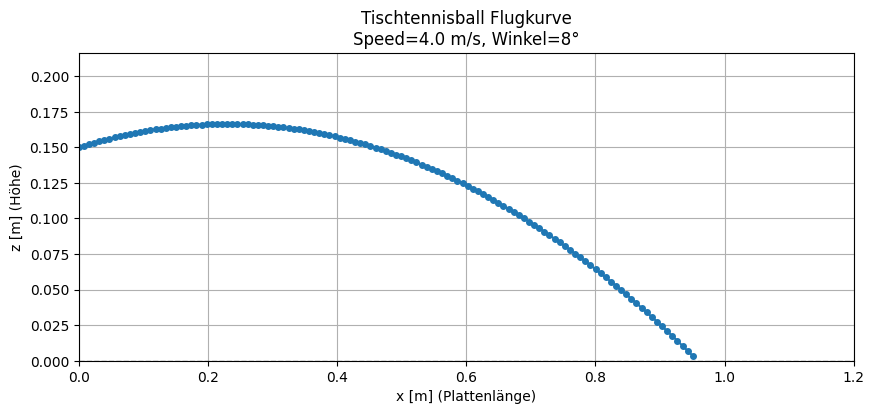

In [26]:
# Parameter für den Tisch und die Simulation
g = 9.81            # Erdbeschleunigung [m/s^2]
dt = 0.002          # Zeitschritt
timesteps = 2000
ausschnitt = 1.2    # Bildausschnitt: halbe Tischtennisplatte (~1.37 m) + etwas mehr

# --- NEUE Steuerparameter ---
speed = 4.0          # Anfangsgeschwindigkeit [m/s]
angle_deg = 8        # Winkel in Grad (0 = horizontal, positiv = nach oben)
# ----------------------------

# Berechnung der Geschwindigkeitskomponenten
angle_rad = np.deg2rad(angle_deg)
vx = speed * np.cos(angle_rad)
vz = speed * np.sin(angle_rad)

# Startbedingungen
pos = np.array([0.0, 0.0, 0.15])   # Start leicht über Platte (15 cm)
velocity = np.array([vx, 0.0, vz])

# Arrays speichern
positions = [pos.copy()]

for t in range(timesteps):
    pos = pos + velocity * dt
    velocity[2] -= g * dt   # Gravitation auf z
    
    if pos[2] <= 0:   # Ball erreicht Platte
        break
    
    positions.append(pos.copy())

positions = np.array(positions)

# Nur den Bildausschnitt zeigen (halbe Platte + bisschen mehr)
mask = positions[:,0] <= ausschnitt
positions_cut = positions[mask]

# Plot
plt.figure(figsize=(10, 4))
plt.plot(positions_cut[:,0], positions_cut[:,2], 'o-', markersize=4)

plt.title(f"Tischtennisball Flugkurve\nSpeed={speed} m/s, Winkel={angle_deg}°")
plt.xlabel("x [m] (Plattenlänge)")
plt.ylabel("z [m] (Höhe)")
plt.grid(True)

plt.xlim(0, ausschnitt)
plt.ylim(0, positions_cut[:,2].max() + 0.05)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)


plt.show()

In [27]:
import sys
sys.path.append("../src/utils/")
sys.path.append("../src/utils/IEBCS/")
import eventIO
import numpy as np

In [28]:
ev = eventIO.load_hdf5("/data/lkolmar/datasets/topspin_fit_to_max/data/00000/00000_events.hdf5")

In [29]:
data = np.array([ev.get_x(), ev.get_y(), ev.get_p(), ev.get_ts()])

In [30]:
print(np.max(data[3] / 1000000), np.min(data[3]) / 1000000)

0.205303 1.1e-05


In [31]:
np.save("/data/lkolmar/test.np", data)

In [32]:
print(data.shape)

(4, 1134745)


# Next try 

In [54]:
frames = 500

y_start = -0.45
z_start = 0.25
y_end = 0.45
z_end = -0.25

gravity_z = -10
gravity_z = gravity_z / 10000

speed_y = np.abs(y_end - y_start) / frames
speed_z = 0

In [55]:
position = np.array([0.0, y_start, 0.0])
positions = [position.copy()]

for i in range(frames-1):
    position[1] += speed_y
    position[2] += speed_z
    speed_z -= gravity_z / frames
    positions.append(position.copy())

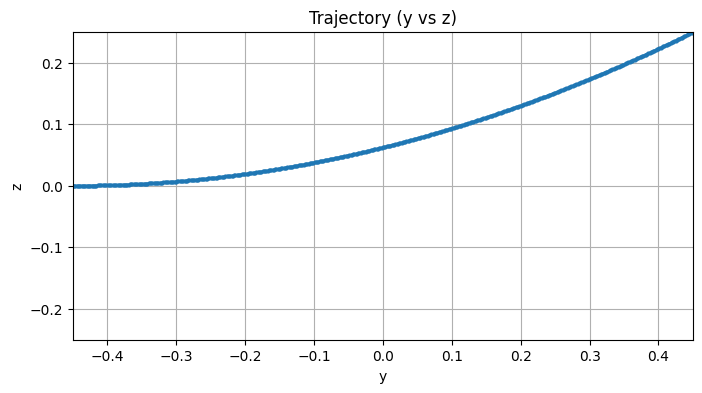

In [56]:
positions_arr = np.array(positions)
plt.figure(figsize=(8, 4))
plt.plot(positions_arr[:, 1], positions_arr[:, 2], marker='o', markersize=2, linestyle='-')
plt.xlabel('y')
plt.ylabel('z')
plt.xlim(y_start, y_end)
plt.ylim(z_end, z_start)
plt.title('Trajectory (y vs z)')
plt.grid(True)
plt.show()

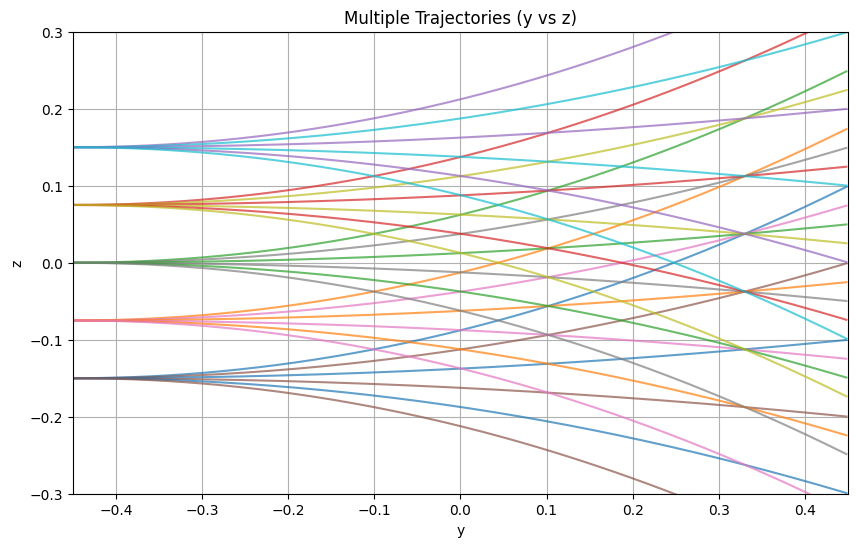

In [57]:
frames = 500
y_start = -0.45
y_end = 0.45

# Define ranges for gravity and starting z
gravity_z_values = np.linspace(-10, 10, 6)  # 6 different gravities
z_start_values = np.linspace(-0.15, 0.15, 5)  # 5 different starting positions

plt.figure(figsize=(10, 6))

# Loop through each combination of gravity and z_start
for gravity_z in gravity_z_values:
    gravity_z /= 10000  # scale as in original code
    
    for z_start in z_start_values:
        speed_y = np.abs(y_end - y_start) / frames
        speed_z = 0
        position = np.array([0.0, y_start, z_start])
        positions = [position.copy()]

        for i in range(frames - 1):
            position[1] += speed_y
            position[2] += speed_z
            speed_z -= gravity_z / frames
            positions.append(position.copy())

        positions_arr = np.array(positions)
        plt.plot(positions_arr[:, 1], positions_arr[:, 2], linestyle='-', alpha=0.7)

plt.xlabel('y')
plt.ylabel('z')
plt.xlim(y_start, y_end)
plt.ylim(-0.3, 0.3)
plt.title('Multiple Trajectories (y vs z)')
plt.grid(True)
plt.show()

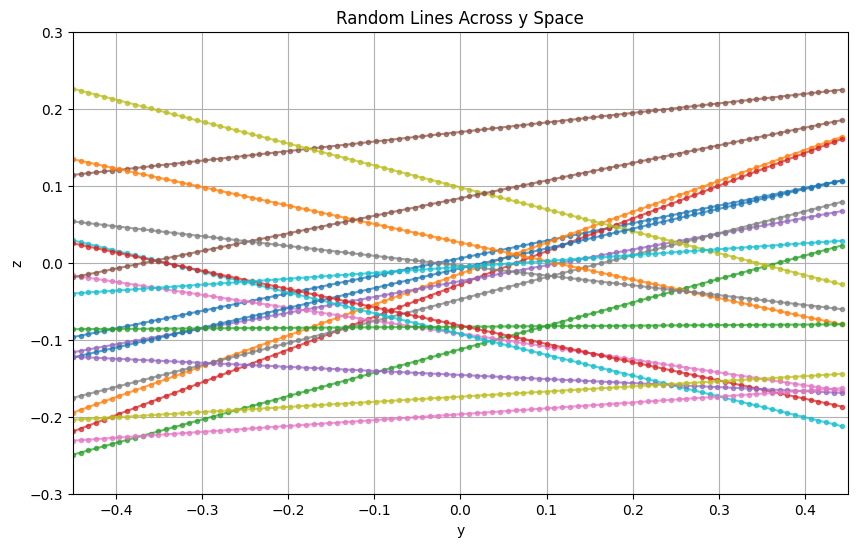

In [63]:
frames = 500
y_start = -0.45
y_end = 0.45

num_lines = 20  # number of random lines

plt.figure(figsize=(10, 6))

for _ in range(num_lines):
    # Random start and end z positions
    z_start = np.random.uniform(-0.25, 0.25)
    z_end = np.random.uniform(-0.25, 0.25)
    
    # Generate y and corresponding z linearly
    y_vals = np.linspace(y_start, y_end, frames)
    z_vals = np.linspace(z_start, z_end, frames)
    
    # Sample points
    sampled_idx = np.arange(0, frames, 5)
    plt.plot(y_vals[sampled_idx], z_vals[sampled_idx], linestyle='-', marker='o', markersize=3, alpha=0.7)

plt.xlabel('y')
plt.ylabel('z')
plt.xlim(y_start, y_end)
plt.ylim(-0.3, 0.3)
plt.title('Random Lines Across y Space')
plt.grid(True)
plt.show()

In [59]:
print(y_vals.shape, z_vals.shape)

(500,) (500,)
